# Домашнее задание 10-11

In [30]:
import os
import math
import time
import random
from typing import Tuple, Dict, List
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import os
import csv

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0
torchvision: 0.25.0


In [45]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = "./data"

BATCH_SIZE = 256
EPOCHS = 4

Device: cpu


In [32]:
x = torch.tensor([1,2,3])
x_gpu = x.to(DEVICE)
print('x_gpu.device:', x_gpu.device)

z = torch.ones((2, 3), dtype=torch.float32, device=DEVICE)
print('z:', z, z.device, z.dtype)

x_gpu.device: cpu
z: tensor([[1., 1., 1.],
        [1., 1., 1.]]) cpu torch.float32


## Часть A (S10) - Датасет для классификации

In [33]:
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

base_train_transform_A = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

aug_train_transform_A = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

resnet_train_transform_A = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_transform_A = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


In [34]:
train_dataset_A_base = torchvision.datasets.Flowers102(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=base_train_transform_A,
)

train_dataset_A_aug = torchvision.datasets.Flowers102(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=aug_train_transform_A,
)

val_dataset_A = torchvision.datasets.Flowers102(
    root=DATA_DIR,
    split="val",
    download=False,
    transform=val_transform_A,
)

test_dataset_A = torchvision.datasets.Flowers102(
    root=DATA_DIR,
    split="test",
    download=False,
    transform=val_transform_A,
)


In [35]:
BATCH_SIZE = 128

train_loader_A_base = DataLoader(
    train_dataset_A_base,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(DEVICE.type == "cuda"),
)

train_loader_A_aug = DataLoader(
    train_dataset_A_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader_A = DataLoader(
    val_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader_A = DataLoader(
    test_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=(DEVICE.type == "cuda"),
)


Batch size: 128
x.shape: torch.Size([128, 3, 224, 224])
y.shape: torch.Size([128])


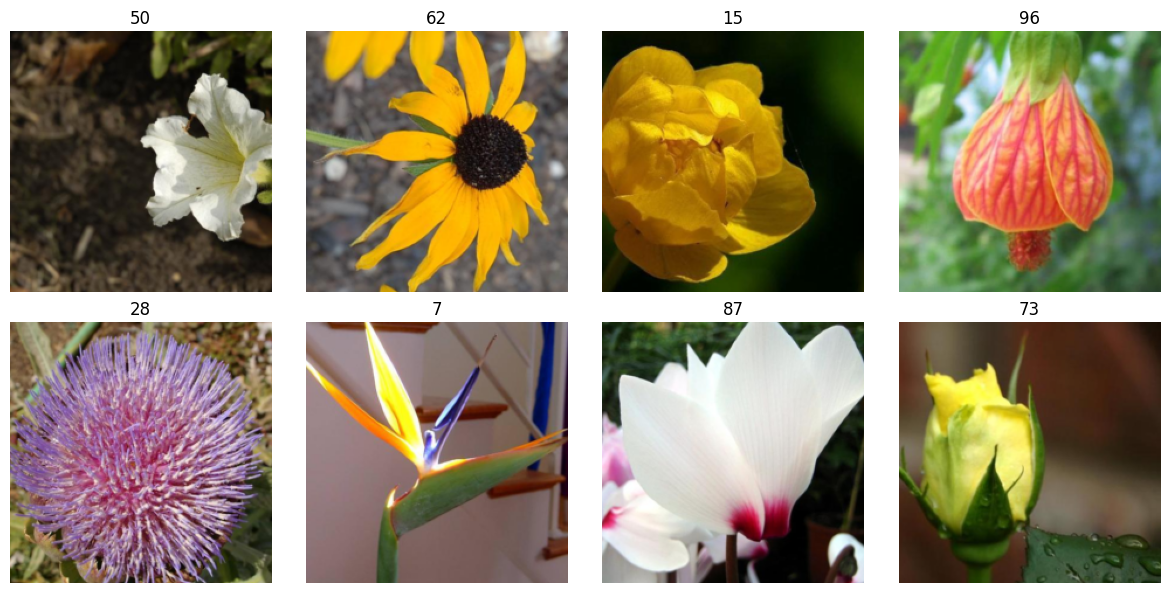

In [36]:
images, labels = next(iter(train_loader_A_base))
print("Batch size:", images.size(0))
print("x.shape:", images.shape)
print("y.shape:", labels.shape)


mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def imshow(ax, img_tensor, title=None):
    img = img_tensor.cpu() * std + mean  # денормализация
    img = img.permute(1, 2, 0).numpy()
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.axis("off")
    if title is not None:
        ax.set_title(str(title))

fig, axs = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axs.flatten()):
    if i >= images.size(0):
        ax.axis("off")
        continue
    imshow(ax, images[i], title=int(labels[i].item()))

plt.tight_layout()
plt.show()

## Часть B (S11): датасет для детекции или сегментации

In [37]:
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

img_size = 256

def joint_transform(image, mask):
    image = F.resize(image, (img_size, img_size))
    mask = F.resize(mask, (img_size, img_size), interpolation=InterpolationMode.NEAREST)

    image = F.to_tensor(image)
    image = F.normalize(
        image,
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )

    mask = F.pil_to_tensor(mask).squeeze(0).long() - 1   # было 1,2,3 -> станет 0,1,2
    return image, mask

trainval_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
    transforms=joint_transform,
)

sample_img, sample_mask = trainval_dataset[0]
print(type(sample_img), sample_img.shape, sample_img.dtype)
print(type(sample_mask), sample_mask.shape, sample_mask.dtype)
print(torch.unique(sample_mask))


<class 'torch.Tensor'> torch.Size([3, 256, 256]) torch.float32
<class 'torch.Tensor'> torch.Size([256, 256]) torch.int64
tensor([0, 1, 2])


In [38]:
train_loader_B = DataLoader(
    trainval_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

images, masks = next(iter(train_loader_B))

print("Batch size:", images.size(0))
print("images.shape:", images.shape)   # [B, 3, 256, 256]
print("masks.shape:", masks.shape)     # [B, 256, 256]
print("mask unique values:", torch.unique(masks))


Batch size: 4
images.shape: torch.Size([4, 3, 256, 256])
masks.shape: torch.Size([4, 256, 256])
mask unique values: tensor([0, 1, 2])


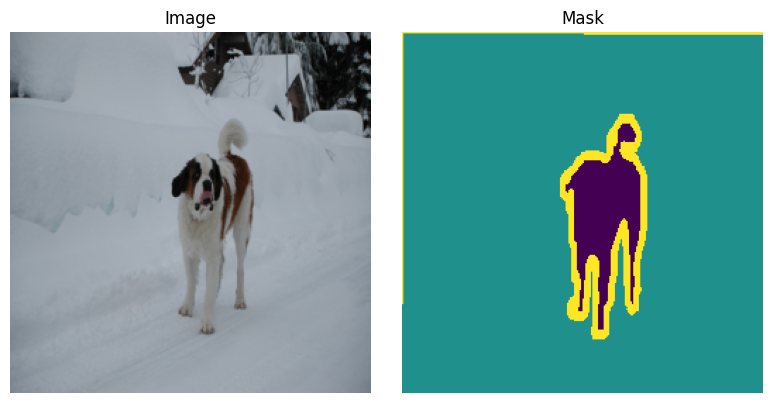

In [39]:
imagenet_mean_t = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
imagenet_std_t  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def denormalize(img_batch):
    return img_batch * imagenet_std_t + imagenet_mean_t

def show_sample(img, mask):
    img = (img.unsqueeze(0))
    img = denormalize(img)[0].clamp(0, 1)
    img_np = img.permute(1, 2, 0).cpu().numpy()

    mask_np = mask.cpu().numpy()

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mask_np, cmap="viridis")
    plt.axis("off")
    plt.title("Mask")
    plt.tight_layout()
    plt.show()


for i in range(1):
    images, mask = next(iter(train_loader_B))
    show_sample(images[0],mask[0])


## Базовые функции обучения и оценки

In [40]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [41]:
def pixel_accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)          # [B, H, W]
    return (preds == y_true).float().mean().item()

def mean_iou_from_logits(logits: torch.Tensor, y_true: torch.Tensor, num_classes: int = 3) -> float:
    preds = torch.argmax(logits, dim=1)  # [B, H, W]

    ious = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        true_cls = (y_true == cls)

        intersection = (pred_cls & true_cls).sum().item()
        union = (pred_cls | true_cls).sum().item()

        if union > 0:
            ious.append(intersection / union)

    if len(ious) == 0:
        return float("nan")
    return sum(ious) / len(ious)

@torch.no_grad()
def evaluate_segmentation(model, loader, criterion, num_classes: int = 3):
    model.eval()

    total_loss = 0.0
    total_pix_acc = 0.0
    total_miou = 0.0
    total_batches = 0
    total_seen = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_pix_acc += pixel_accuracy_from_logits(logits, y) * bs
        total_miou += mean_iou_from_logits(logits, y, num_classes=num_classes) * bs
        total_seen += bs
        total_batches += 1

    return (
        total_loss / total_seen,
        total_pix_acc / total_seen,
        total_miou / total_seen,
    )

@torch.no_grad()
def show_predictions(model, loader, n: int = 3):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(DEVICE), y.to(DEVICE)

    logits = model(x)
    preds = torch.argmax(logits, dim=1)

    x_denorm = denormalize(x.cpu()).clamp(0, 1)

    for i in range(min(n, x.size(0))):
        img = x_denorm[i].permute(1, 2, 0).numpy()
        true_mask = y[i].cpu().numpy()
        pred_mask = preds[i].cpu().numpy()

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap="viridis", vmin=0, vmax=2)
        plt.title("True mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask, cmap="viridis", vmin=0, vmax=2)
        plt.title("Pred mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

def append_run_csv(
    path: str,
    row: dict,
):
    file_exists = os.path.exists(path)

    with open(path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)

## Часть A (S10): классификация, аугментации и transfer learning (обязательно)

## C1 (simple-cnn-base)

In [48]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 102):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
cnn_c1 = SimpleCNN(num_classes=102).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_c1.parameters(), lr=1e-3, weight_decay=1e-4)

hist_c1 = fit(
    cnn_c1,
    train_loader_A_base,
    val_loader_A,
    optimizer,
    criterion,
    epochs=EPOCHS,
    verbose=True,
)

best_val_acc_c1 = float(np.nanmax(hist_c1["val_acc"]))
print("C1 best_val_acc:", best_val_acc_c1)


Epoch 01/4 | train loss 4.6285, acc 0.010 | val loss 4.5355, acc 0.036 | 70.0s
Epoch 02/4 | train loss 4.4161, acc 0.037 | val loss 4.2011, acc 0.048 | 70.3s


## C2 (simple-cnn-aug)

In [ ]:
cnn_c2 = SimpleCNN(num_classes=102).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_c2.parameters(), lr=1e-3, weight_decay=1e-4)

hist_c2 = fit(
    cnn_c2,
    train_loader_A_aug,
    val_loader_A,
    optimizer,
    criterion,
    epochs=EPOCHS,
    verbose=True,
)

best_val_acc_c2 = float(np.nanmax(hist_c2["val_acc"]))
print("C2 best_val_acc:", best_val_acc_c2)


## C3 (resnet18-head-only)

In [ ]:
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 102)
model = model.to(DEVICE)

## C4 (resnet18-finetune)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False

for p in model.layer4.parameters():
    p.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 102)
model = model.to(DEVICE)
